In [762]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [763]:
df=pd.read_csv('cleaned_dataset.csv', encoding='latin1')

# Detailed Transformation Scenarios (15–20)

## 1. Exceedance flags vs daily/hourly standards

In [764]:
df['PM2_5_flag_daily']=df['PM2_5']>df['Pollutant_standard_daily']
df['PM2_5_flag_hourly']=df['PM2_5']>df['Pollutant_standard_hourly']

In [765]:
df['PM2_5_flag_daily'].head()

0    True
1    True
2    True
3    True
4    True
Name: PM2_5_flag_daily, dtype: bool

In [766]:
df['PM2_5_flag_daily'].unique()

array([ True, False])

In [767]:
ans={True:1,False:0}
df['PM2_5_flag_daily']=df['PM2_5_flag_daily'].map(ans)

In [768]:
df['PM2_5_flag_daily'].unique()

array([1, 0])

In [769]:
df['PM2_5_flag_daily']

0        1
1        1
2        1
3        1
4        1
        ..
14878    1
14879    1
14880    1
14881    1
14882    1
Name: PM2_5_flag_daily, Length: 14883, dtype: int64

In [770]:
df['PM2_5_flag_hourly']=df['PM2_5_flag_hourly'].map(ans)

In [771]:
df['PM2_5_flag_hourly'].unique()

array([1, 0])

In [772]:
df['PM2_5_flag_hourly']

0        1
1        1
2        1
3        1
4        1
        ..
14878    1
14879    1
14880    1
14881    1
14882    0
Name: PM2_5_flag_hourly, Length: 14883, dtype: int64

In [773]:
df['SO2_flag_daily']=df['SO2']>df['Pollutant_standard_daily']
df['SO2_flag_hourly']=df['SO2']>df['Pollutant_standard_hourly']


In [774]:
df['SO2_flag_daily'].head()

0     True
1     True
2    False
3     True
4     True
Name: SO2_flag_daily, dtype: bool

In [775]:
df['SO2_flag_daily'].unique()

array([ True, False])

In [776]:
df['SO2_flag_daily']=df['SO2_flag_daily'].map(ans)

In [777]:
df['SO2_flag_daily'].unique()

array([1, 0])

In [778]:
df['SO2_flag_daily']

0        1
1        1
2        0
3        1
4        1
        ..
14878    0
14879    1
14880    0
14881    1
14882    0
Name: SO2_flag_daily, Length: 14883, dtype: int64

In [779]:
df['SO2_flag_hourly']=df['SO2_flag_hourly'].map(ans)

In [780]:
df['SO2_flag_hourly'].unique()

array([0, 1])

In [781]:
df['SO2_flag_hourly']

0        0
1        1
2        0
3        1
4        1
        ..
14878    0
14879    1
14880    0
14881    1
14882    0
Name: SO2_flag_hourly, Length: 14883, dtype: int64

In [782]:
df['NOx_flag_daily']=df['NOx']>df['Pollutant_standard_daily']
df['NOx_flag_hourly']=df['NOx']>df['Pollutant_standard_hourly']


In [783]:
df['NOx_flag_daily'].head()

0    False
1     True
2    False
3     True
4     True
Name: NOx_flag_daily, dtype: bool

In [784]:
df['NOx_flag_daily'].unique()

array([False,  True])

In [785]:
df['NOx_flag_daily']=df['NOx_flag_daily'].map(ans)

In [786]:
df['NOx_flag_daily'].unique()

array([0, 1])

In [787]:
df['NOx_flag_daily']

0        0
1        1
2        0
3        1
4        1
        ..
14878    0
14879    1
14880    0
14881    1
14882    1
Name: NOx_flag_daily, Length: 14883, dtype: int64

In [788]:
df['NOx_flag_hourly']=df['NOx_flag_hourly'].map(ans)

In [789]:
df['NOx_flag_hourly'].unique()

array([0, 1])

In [790]:
df['NOx_flag_hourly']

0        0
1        1
2        0
3        1
4        1
        ..
14878    0
14879    1
14880    0
14881    1
14882    0
Name: NOx_flag_hourly, Length: 14883, dtype: int64

In [791]:
df.loc[1:10,['PM2_5','SO2','NOx','Pollutant_standard_daily','PM2_5_flag_daily','SO2_flag_daily','NOx_flag_daily','Pollutant_standard_hourly','PM2_5_flag_hourly','SO2_flag_hourly','NOx_flag_hourly']]

,PM2_5,SO2,NOx,Pollutant_standard_daily,PM2_5_flag_daily,SO2_flag_daily,NOx_flag_daily,Pollutant_standard_hourly,PM2_5_flag_hourly,SO2_flag_hourly,NOx_flag_hourly
1,83870.00,29840.00,35490.00,56.9,1,1,1,66.5,1,1,1
2,155.72,18.32,50.01,64.9,1,0,0,145.8,1,0,0
3,153280.00,62150.00,28010.00,40.3,1,1,1,107.4,1,1,1
4,71150.00,11060.00,122410.00,46.3,1,1,1,176.4,1,1,1
5,279.26,20.39,112.83,28.8,1,0,1,76.7,1,0,1
6,59.58,30.52,69.09,80.8,0,0,0,57.3,1,0,1
7,152.31,15.26,82.44,99.8,1,0,0,55.0,1,0,1
8,115640.00,13250.00,38920.00,67.4,1,1,1,133.7,1,1,1
9,117070.00,44240.00,35770.00,91.0,1,1,1,67.5,1,1,1
10,125500.00,29540.00,98540.00,90.4,1,1,1,191.2,1,1,1


## 2. Pollutant AQI sub‑index computation and overall AQI

In [792]:
PM2_5_limit=60
SO2_limit=80
NOx_limit=80

In [793]:
df['PM2_5_SubIndex']=(df['PM2_5']/60) * 100
df['SO2_SubIndex']=(df['SO2']/80) * 100
df['NOx_SubIndex']=(df['NOx']/80) * 100

In [794]:
df['Overall_AQI']=df[['PM2_5_SubIndex','SO2_SubIndex','NOx_SubIndex']].max(axis=1)

In [795]:
df.loc[1:10,['PM2_5','SO2','NOx','PM2_5_SubIndex','SO2_SubIndex','NOx_SubIndex','Overall_AQI']]

,PM2_5,SO2,NOx,PM2_5_SubIndex,SO2_SubIndex,NOx_SubIndex,Overall_AQI
1,83870.00,29840.00,35490.00,139783.333333,37300.0000,44362.5000,139783.333333
2,155.72,18.32,50.01,259.533333,22.9000,62.5125,259.533333
3,153280.00,62150.00,28010.00,255466.666667,77687.5000,35012.5000,255466.666667
4,71150.00,11060.00,122410.00,118583.333333,13825.0000,153012.5000,153012.500000
5,279.26,20.39,112.83,465.433333,25.4875,141.0375,465.433333
6,59.58,30.52,69.09,99.300000,38.1500,86.3625,99.300000
7,152.31,15.26,82.44,253.850000,19.0750,103.0500,253.850000
8,115640.00,13250.00,38920.00,192733.333333,16562.5000,48650.0000,192733.333333
9,117070.00,44240.00,35770.00,195116.666667,55300.0000,44712.5000,195116.666667
10,125500.00,29540.00,98540.00,209166.666667,36925.0000,123175.0000,209166.666667


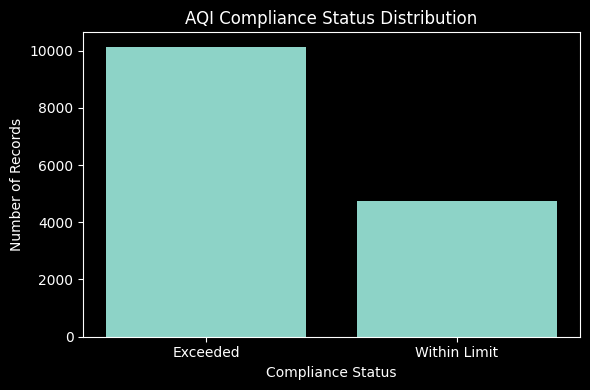

In [796]:
aqi_counts = df["Compliance_Status"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(aqi_counts.index, aqi_counts.values)

plt.title("AQI Compliance Status Distribution")
plt.xlabel("Compliance Status")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

## 3. Emission load (kg/day) from concentration and flow

In [797]:
df["Flow_Rate"] = 1500

df["PM2_5_Emission_Load"] = (df["PM2_5"] * df["Flow_Rate"] * 24) / 1000
df["SO2_Emission_Load"] = (df["SO2"] * df["Flow_Rate"] * 24) / 1000
df["NOx_Emission_Load"] = (df["NOx"] * df["Flow_Rate"] * 24) / 1000

In [798]:
df[["Flow_Rate", "PM2_5", "PM2_5_Emission_Load", "SO2", "SO2_Emission_Load", "NOx", "NOx_Emission_Load"]].head()

,Flow_Rate,PM2_5,PM2_5_Emission_Load,SO2,SO2_Emission_Load,NOx,NOx_Emission_Load
0,1500,157.84,5682.24,50.28,1810.08,26.06,938.16
1,1500,83870.00,3019320.00,29840.00,1074240.00,35490.00,1277640.00
2,1500,155.72,5605.92,18.32,659.52,50.01,1800.36
3,1500,153280.00,5518080.00,62150.00,2237400.00,28010.00,1008360.00
4,1500,71150.00,2561400.00,11060.00,398160.00,122410.00,4406760.00


## 4. Rolling 24‑hour averages and percentiles

In [799]:
df["TS"] = pd.to_datetime(df["TS"])
df = df.sort_values(["Plant_ID", "TS"]).reset_index(drop=True)

In [800]:
df["PM2_5_Rolling_Avg"] = (df.groupby("Plant_ID")["PM2_5"].rolling(window=24).mean().reset_index(level=0, drop=True)) 
df["PM2_5_Rolling_Avg"] = df["PM2_5_Rolling_Avg"].fillna(df["PM2_5"])

df["SO2_Rolling_Avg"] = (df.groupby("Plant_ID")["SO2"].rolling(window=24).mean().reset_index(level=0, drop=True))
df["SO2_Rolling_Avg"] = df["SO2_Rolling_Avg"].fillna(df["SO2"])

df["NOx_Rolling_Avg"] = (df.groupby("Plant_ID")["NOx"].rolling(window=24).mean().reset_index(level=0, drop=True))
df["NOx_Rolling_Avg"] = df["NOx_Rolling_Avg"].fillna(df["NOx"])

In [801]:
df["PM2_5_25th_Percentile"] = df["PM2_5"].quantile(0.25)
df["PM2_5_50th_Percentile"] = df["PM2_5"].quantile(0.50)
df["PM2_5_75th_Percentile"] = df["PM2_5"].quantile(0.75)

df["SO2_25th_Percentile"] = df["SO2"].quantile(0.25)
df["SO2_50th_Percentile"] = df["SO2"].quantile(0.50)  
df["SO2_75th_Percentile"] = df["SO2"].quantile(0.75)

df["NOx_25th_Percentile"] = df["NOx"].quantile(0.25)
df["NOx_50th_Percentile"] = df["NOx"].quantile(0.50)
df["NOx_75th_Percentile"] = df["NOx"].quantile(0.75)

In [802]:
df["PM2_5_75th_Percentile"].head(40)

0     89970.0
1     89970.0
2     89970.0
3     89970.0
4     89970.0
5     89970.0
6     89970.0
7     89970.0
8     89970.0
9     89970.0
10    89970.0
11    89970.0
12    89970.0
13    89970.0
14    89970.0
15    89970.0
16    89970.0
17    89970.0
18    89970.0
19    89970.0
20    89970.0
21    89970.0
22    89970.0
23    89970.0
24    89970.0
25    89970.0
26    89970.0
27    89970.0
28    89970.0
29    89970.0
30    89970.0
31    89970.0
32    89970.0
33    89970.0
34    89970.0
35    89970.0
36    89970.0
37    89970.0
38    89970.0
39    89970.0
Name: PM2_5_75th_Percentile, dtype: float64

In [803]:
print(df[["Plant_ID","TS","PM2_5","PM2_5_Rolling_Avg","PM2_5_25th_Percentile","PM2_5_50th_Percentile","PM2_5_75th_Percentile"]].head())

  Plant_ID                  TS      PM2_5  PM2_5_Rolling_Avg  \
0    PL-01 2026-01-03 06:18:00     157.84             157.84   
1    PL-01 2026-01-03 11:59:00   83870.00           83870.00   
2    PL-01 2026-01-03 15:30:00     155.72             155.72   
3    PL-01 2026-01-03 15:35:00  153280.00          153280.00   
4    PL-01 2026-01-03 15:54:00   71150.00           71150.00   

   PM2_5_25th_Percentile  PM2_5_50th_Percentile  PM2_5_75th_Percentile  
0                 93.945                 189.79                89970.0  
1                 93.945                 189.79                89970.0  
2                 93.945                 189.79                89970.0  
3                 93.945                 189.79                89970.0  
4                 93.945                 189.79                89970.0  


In [804]:
print(df[["Plant_ID","TS","SO2","SO2_Rolling_Avg","SO2_25th_Percentile","SO2_50th_Percentile","SO2_75th_Percentile"]].head())

  Plant_ID                  TS       SO2  SO2_Rolling_Avg  \
0    PL-01 2026-01-03 06:18:00     50.28            50.28   
1    PL-01 2026-01-03 11:59:00  29840.00         29840.00   
2    PL-01 2026-01-03 15:30:00     18.32            18.32   
3    PL-01 2026-01-03 15:35:00  62150.00         62150.00   
4    PL-01 2026-01-03 15:54:00  11060.00         11060.00   

   SO2_25th_Percentile  SO2_50th_Percentile  SO2_75th_Percentile  
0                26.27                50.48              25490.0  
1                26.27                50.48              25490.0  
2                26.27                50.48              25490.0  
3                26.27                50.48              25490.0  
4                26.27                50.48              25490.0  


In [805]:
print(df[["Plant_ID","TS","NOx","NOx_Rolling_Avg","NOx_25th_Percentile","NOx_50th_Percentile","NOx_75th_Percentile"]].head())

  Plant_ID                  TS        NOx  NOx_Rolling_Avg  \
0    PL-01 2026-01-03 06:18:00      26.06            26.06   
1    PL-01 2026-01-03 11:59:00   35490.00         35490.00   
2    PL-01 2026-01-03 15:30:00      50.01            50.01   
3    PL-01 2026-01-03 15:35:00   28010.00         28010.00   
4    PL-01 2026-01-03 15:54:00  122410.00        122410.00   

   NOx_25th_Percentile  NOx_50th_Percentile  NOx_75th_Percentile  
0                39.08                73.82              36515.0  
1                39.08                73.82              36515.0  
2                39.08                73.82              36515.0  
3                39.08                73.82              36515.0  
4                39.08                73.82              36515.0  


## 5. Source contribution indicators (wind‑weighted).

In [806]:
df['Wind_Weight_PM2_5']=(df['Wind_speed_m_s']*df['PM2_5']).round(2)
df['Wind_Weight_SO2']=(df['Wind_speed_m_s']*df['SO2']).round(2)
df['Wind_Weight_NOx']=(df['Wind_speed_m_s']*df['NOx']).round(2)

In [807]:
df.loc[1:10,['PM2_5','Wind_Weight_PM2_5','SO2','Wind_Weight_SO2','NOx','Wind_Weight_NOx']]

,PM2_5,Wind_Weight_PM2_5,SO2,Wind_Weight_SO2,NOx,Wind_Weight_NOx
1,83870.00,410124.30,29840.00,145917.60,35490.00,173546.10
2,155.72,431.34,18.32,50.75,50.01,138.53
3,153280.00,1511340.80,62150.00,612799.00,28010.00,276178.60
4,71150.00,919969.50,11060.00,143005.80,122410.00,1582761.30
5,279.26,994.17,20.39,72.59,112.83,401.67
6,59.58,477.83,30.52,244.77,69.09,554.10
7,152.31,2238.96,15.26,224.32,82.44,1211.87
8,115640.00,1209594.40,13250.00,138595.00,38920.00,407103.20
9,117070.00,648567.80,44240.00,245089.60,35770.00,198165.80
10,125500.00,613695.00,29540.00,144450.60,98540.00,481860.60


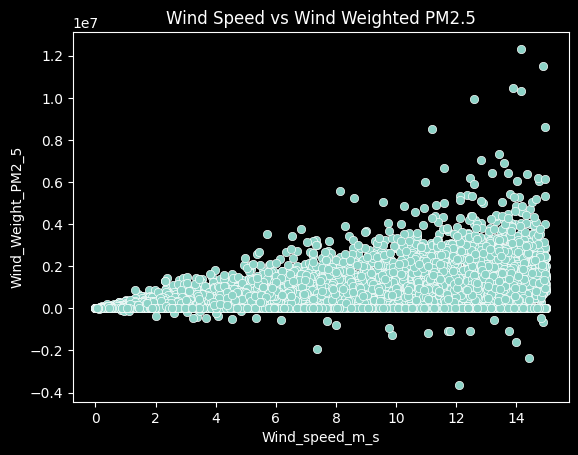

In [808]:
sns.scatterplot(data=df,x="Wind_speed_m_s",y="Wind_Weight_PM2_5")

plt.title("Wind Speed vs Wind Weighted PM2.5")
plt.show()

## 6. Compliance rate per plant/month.

In [809]:
df[["Plant_ID", "TS", "Compliance_Status"]].head()

,Plant_ID,TS,Compliance_Status
0,PL-01,2026-01-03 06:18:00,Exceeded
1,PL-01,2026-01-03 11:59:00,Exceeded
2,PL-01,2026-01-03 15:30:00,Exceeded
3,PL-01,2026-01-03 15:35:00,Exceeded
4,PL-01,2026-01-03 15:54:00,Exceeded


In [810]:
df["Month"] = df["TS"].dt.to_period("M")

In [811]:
compliance = (df.groupby(["Plant_ID", "Month"])["Compliance_Status"].apply(lambda x: (x == "Within Limit").mean() * 100).reset_index(name="Compliance_Rate (%)"))

In [812]:
compliance["Compliance_Rate (%)"] = compliance["Compliance_Rate (%)"].round(2)

In [813]:
compliance.head()

,Plant_ID,Month,Compliance_Rate (%)
0,PL-01,2026-01,19.05
1,PL-01,2026-02,38.71
2,PL-01,2026-03,33.68
3,PL-01,2026-04,35.00
4,PL-01,2026-05,47.37


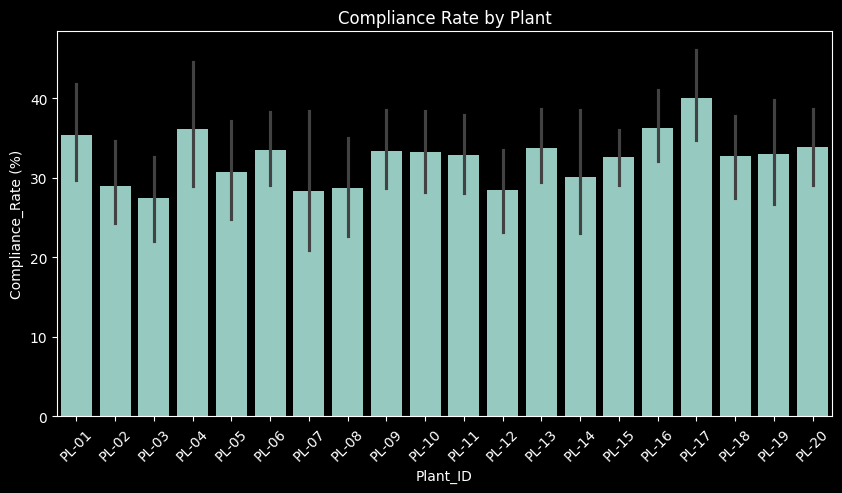

In [814]:
plt.figure(figsize=(10,5))
sns.barplot(data=compliance,x="Plant_ID",y="Compliance_Rate (%)")

plt.title("Compliance Rate by Plant")
plt.xticks(rotation=45)
plt.show()

## 7. Episode detection (high pollution events).

In [815]:
df['PM2_5_Status'].unique()

array(['Exceeded', 'Within Limit'], dtype=object)

In [816]:
df['SO2_Status'].unique()

array(['Within Limit', 'Exceeded'], dtype=object)

In [817]:
df['NOx_Status'].unique()

array(['Within Limit', 'Exceeded'], dtype=object)

In [818]:
df['Pollution_Event']='Within Limit'
df['Pollution_Event']=(df['PM2_5_Status']=='Exceeded') | (df['SO2_Status']=='Exceeded') | (df['NOx_Status']=='Exceeded')

In [819]:
df['Pollution_Event'].unique()

array([ True, False])

In [820]:
df['Pollution_Event']=df['Pollution_Event'].replace(True,'High_Pollution_Event')
df['Pollution_Event']=df['Pollution_Event'].replace(False,'Within Limit')

In [821]:
df['Pollution_Event']

0        High_Pollution_Event
1        High_Pollution_Event
2        High_Pollution_Event
3        High_Pollution_Event
4        High_Pollution_Event
                 ...         
14878    High_Pollution_Event
14879    High_Pollution_Event
14880    High_Pollution_Event
14881    High_Pollution_Event
14882            Within Limit
Name: Pollution_Event, Length: 14883, dtype: object

In [822]:
df['Pollution_Event'].value_counts()

Pollution_Event
High_Pollution_Event    10129
Within Limit             4754
Name: count, dtype: int64

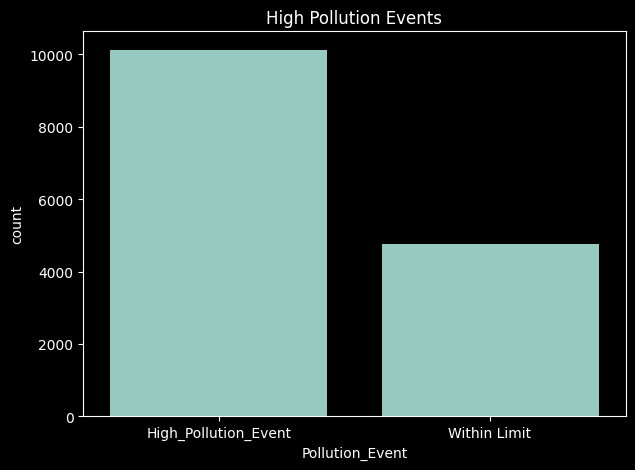

In [823]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="Pollution_Event")
plt.title("High Pollution Events")
plt.show()

## 8. Spatial interpolation grids for maps.

In [824]:
df["Grid_Lat"] = df["Latitude"].round(1)
df["Grid_Lon"] = df["Longitude"].round(1)
grid_data = (df.groupby(["Grid_Lat", "Grid_Lon"])[["PM2_5", "SO2", "NOx"]].mean().reset_index())
grid_data.rename(columns={"PM2_5": "Average_PM2_5", "SO2": "Average_SO2", "NOx": "Average_NOx"}, inplace=True)

In [825]:
print(grid_data.head(30))

    Grid_Lat  Grid_Lon  Average_PM2_5    Average_SO2   Average_NOx
0       13.1      78.0   50175.937984   15494.811366  20562.035066
1       13.3      80.3   49124.689318  145894.551260  18745.272297
2       13.3      81.7   49139.933022   13800.482663  18187.122215
3       13.5      76.0   47923.428198   13497.554299  18788.513618
4       13.6      78.5   49714.771755  145161.896835  18765.752234
5       13.9      77.0   52763.057373   14657.939035  20350.024973
6       13.9      78.6   53085.132735   16043.630260  19609.948741
7       14.2      76.6   49242.216419   15039.532344  21486.470078
8       14.2      77.5   49877.875623  276762.723827  20962.752818
9       14.2      77.6   51158.634220   13379.944630  20739.550754
10      14.3      78.5   55629.475803   14989.686144  20727.235032
11      14.4      79.6   50608.554831   13863.111737  18956.217218
12      14.7      80.6   46340.634616  152468.787329  19309.525274
13      14.9      81.7   51748.986981  147653.912739  19908.00

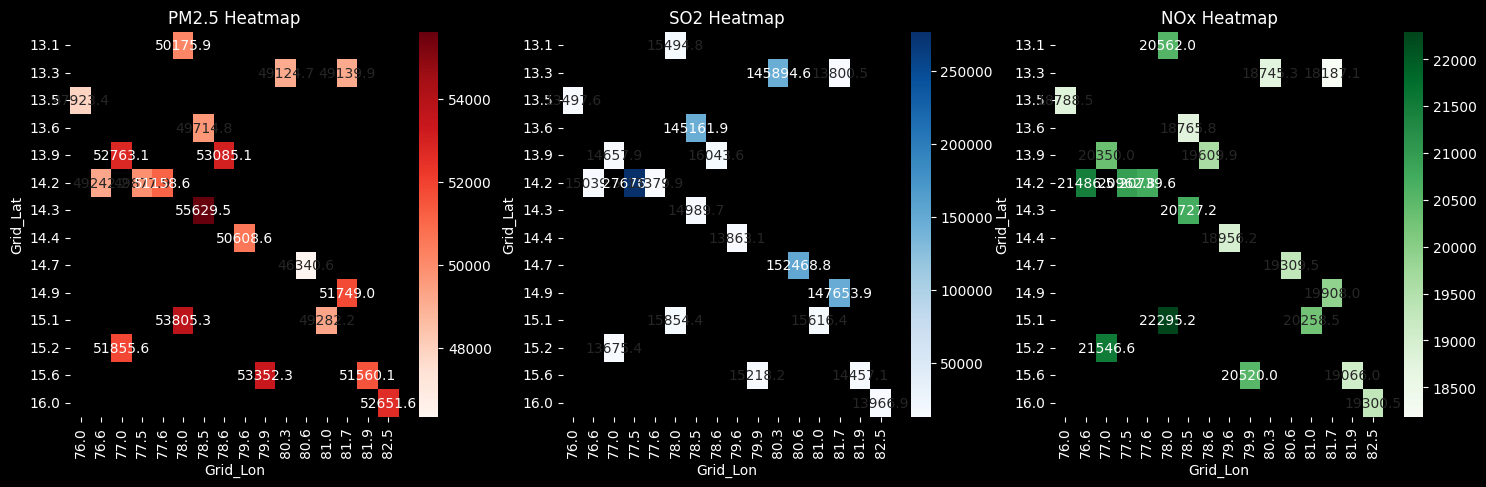

In [826]:
pm = grid_data.pivot_table(values="Average_PM2_5", index="Grid_Lat", columns="Grid_Lon", aggfunc="mean")
so2 = grid_data.pivot_table(values="Average_SO2", index="Grid_Lat", columns="Grid_Lon", aggfunc="mean")
nox = grid_data.pivot_table(values="Average_NOx", index="Grid_Lat", columns="Grid_Lon", aggfunc="mean")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(pm, annot=True, cmap="Reds", fmt=".1f", ax=axes[0])
axes[0].set_title("PM2.5 Heatmap")

sns.heatmap(so2, annot=True, cmap="Blues", fmt=".1f", ax=axes[1])
axes[1].set_title("SO2 Heatmap")

sns.heatmap(nox, annot=True, cmap="Greens", fmt=".1f", ax=axes[2])
axes[2].set_title("NOx Heatmap")

plt.show()

## 9. Health risk proxy index (PM2.5 exposure).

In [827]:
df['PM2_5'].head()

0       157.84
1     83870.00
2       155.72
3    153280.00
4     71150.00
Name: PM2_5, dtype: float64

In [828]:
df['Health_Risk_Index']=np.where(
    df['PM2_5']<=15,1,
    np.where(
        df['PM2_5']<=35,2,
    np.where(
        df['PM2_5']<=55,3,
        np.where(
                df['PM2_5']<=100,4,5
            )
        )
    )
)

In [829]:
risk_map = {
    1: "Low",
    2: "Moderate",
    3: "High",
    4: "Very High",
    5: "Hazardous"
}

In [830]:
df["Health_Risk"] = df["Health_Risk_Index"].map(risk_map)

In [831]:
df[['PM2_5','Health_Risk']]

,PM2_5,Health_Risk
0,157.84,Hazardous
1,83870.00,Hazardous
2,155.72,Hazardous
3,153280.00,Hazardous
4,71150.00,Hazardous
...,...,...
14878,262.14,Hazardous
14879,52090.00,Hazardous
14880,143.36,Hazardous
14881,182750.00,Hazardous


In [832]:
df[['PM2_5','Health_Risk']]

,PM2_5,Health_Risk
0,157.84,Hazardous
1,83870.00,Hazardous
2,155.72,Hazardous
3,153280.00,Hazardous
4,71150.00,Hazardous
...,...,...
14878,262.14,Hazardous
14879,52090.00,Hazardous
14880,143.36,Hazardous
14881,182750.00,Hazardous


In [833]:
df['Health_Risk'].value_counts()

Health_Risk
Hazardous    10809
Very High     2679
High           910
Moderate       392
Low             93
Name: count, dtype: int64

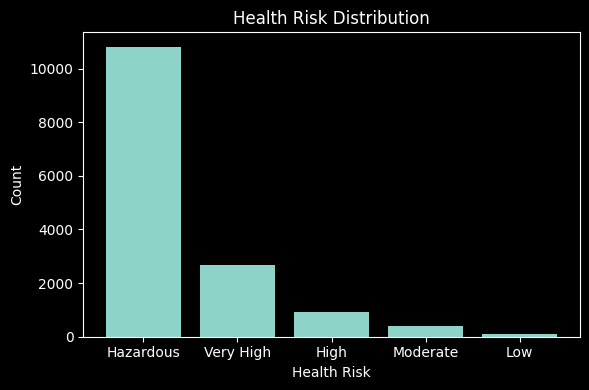

In [834]:
risk = df["Health_Risk"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(risk.index, risk.values)

plt.title("Health Risk Distribution")
plt.xlabel("Health Risk")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## 10. Diurnal and weekly seasonality profiles.

In [835]:
df["Hour"] = df["TS"].dt.hour
df["Day"] = df["TS"].dt.day_name()

In [836]:
hourly_profile = (df.groupby("Hour", as_index=False)[["PM2_5", "SO2", "NOx"]].mean())
weekly_profile = (df.groupby("Day", as_index=False)[["PM2_5", "SO2", "NOx"]].mean())

In [837]:
print(weekly_profile, hourly_profile)

         Day         PM2_5            SO2           NOx
0     Friday  49409.417573   56659.860470  21141.561756
1     Monday  52399.913830   65263.562687  19829.508689
2   Saturday  49948.930645   97524.365569  19541.516239
3     Sunday  51671.751067  115588.010066  19835.796560
4   Thursday  47811.681445   14911.476817  19296.984832
5    Tuesday  52423.681561   14715.954606  20171.821860
6  Wednesday  52932.511384   14949.659658  19977.800842     Hour         PM2_5            SO2           NOx
0      0  49179.923121   14245.344052  19439.219444
1      1  52433.573529   13400.513562  18152.994902
2      2  60064.460954   17550.018426  23484.311176
3      3  46450.539559  183339.106254  19325.185559
4      4  47397.372952  175168.412694  19077.669032
5      5  45097.902766   15196.453657  18451.238665
6      6  53371.408085  173258.931551  20795.596028
7      7  52235.944838   14240.402224  20457.096899
8      8  50034.332831   13567.773881  19744.930091
9      9  49540.393344  175867.6

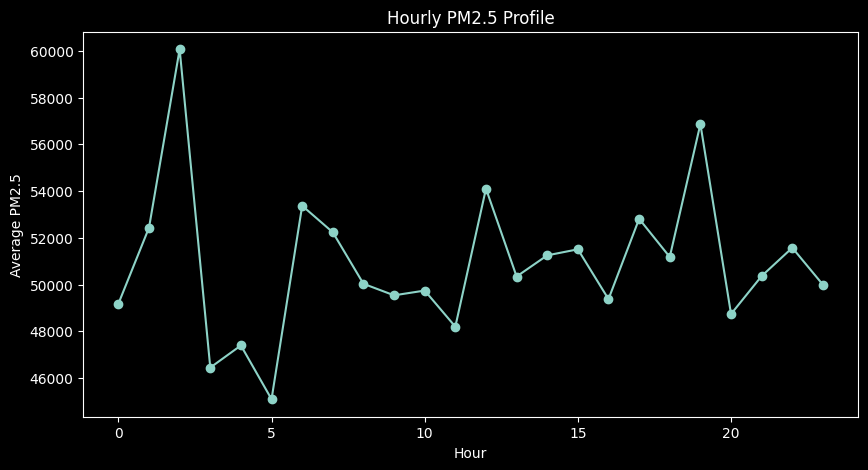

In [838]:
plt.figure(figsize=(10,5))

plt.plot(hourly_profile["Hour"],
         hourly_profile["PM2_5"],
         marker="o")

plt.title("Hourly PM2.5 Profile")
plt.xlabel("Hour")
plt.ylabel("Average PM2.5")
plt.show()

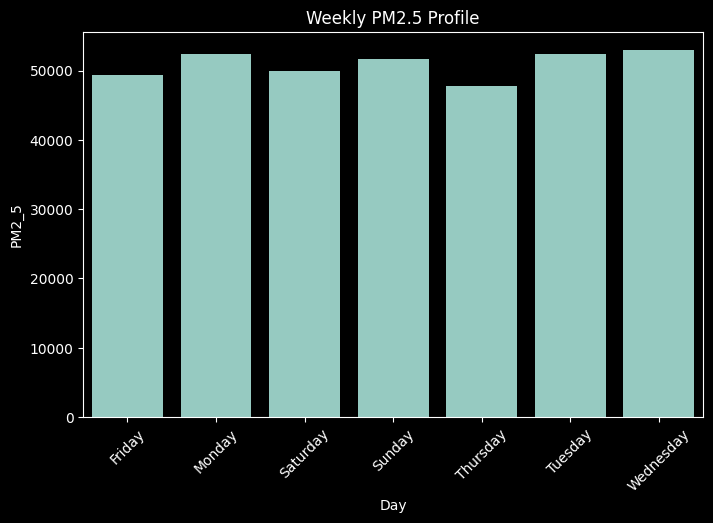

In [839]:
plt.figure(figsize=(8,5))

sns.barplot(data=weekly_profile,
            x="Day",
            y="PM2_5")

plt.title("Weekly PM2.5 Profile")
plt.xticks(rotation=45)
plt.show()

## 11. Meteorology joins (wind, temp, RH).

In [840]:
air_quality = df[[
    "TS",
    "Plant_ID",
    "PM2_5",
    "SO2",
    "NOx",
    "Overall_AQI"
]]

In [841]:
meteorology = df[[
    "TS",
    "Wind_speed_m_s",
    "Wind_dir_deg",
    "Temp_C",
    "RH_pct"
]]

In [842]:
pd.merge(air_quality,meteorology,on='TS',how='left')

,TS,Plant_ID,PM2_5,SO2,NOx,Overall_AQI,Wind_speed_m_s,Wind_dir_deg,Temp_C,RH_pct
0,2026-01-03 06:18:00,PL-01,157.84,50.28,26.06,263.066667,12.91,161.1,39.3,56.5
1,2026-01-03 11:59:00,PL-01,83870.00,29840.00,35490.00,139783.333333,4.89,48.1,25.7,78.2
2,2026-01-03 11:59:00,PL-01,83870.00,29840.00,35490.00,139783.333333,3.65,18.8,40.1,34.6
3,2026-01-03 15:30:00,PL-01,155.72,18.32,50.01,259.533333,2.77,98.4,23.1,74.5
4,2026-01-03 15:30:00,PL-01,155.72,18.32,50.01,259.533333,3.28,195.3,21.9,74.4
...,...,...,...,...,...,...,...,...,...,...
19432,2026-12-04 02:23:00,PL-20,52090.00,41420.00,40990.00,86816.666667,5.46,108.7,30.0,41.5
19433,2026-12-04 03:58:00,PL-20,143.36,67.99,29.64,238.933333,0.06,264.8,37.0,23.6
19434,2026-12-04 04:20:00,PL-20,182750.00,27640.00,50010.00,304583.333333,13.48,295.9,39.9,47.9
19435,2026-12-04 05:14:00,PL-20,74.63,47.47,77.67,124.383333,1.15,73.9,20.2,45.9


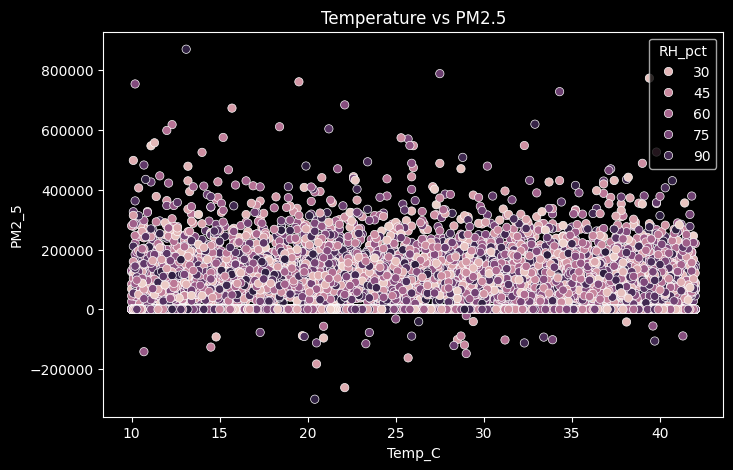

In [843]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,
                x="Temp_C",
                y="PM2_5",
                hue="RH_pct")

plt.title("Temperature vs PM2.5")
plt.show()

## 12. Emission factor application for sectors.

In [844]:
df['Source_Type'].value_counts()

Source_Type
stack         8226
ambient       3645
lab           2280
inspection     732
Name: count, dtype: int64

In [845]:
var = {
    'stack':1.2,
    'ambient':0.7,
    'lab':0.5,
    'inspection':0.9
}

In [846]:
df['Emission_Factor']=df['Source_Type'].map(var)

In [847]:
df['Emission_Factor'].head()

0    0.5
1    1.2
2    0.7
3    1.2
4    0.9
Name: Emission_Factor, dtype: float64

In [848]:
df['Estimated_Emission_PM2_5']=(df['PM2_5'] * df['Emission_Factor']).round(2)
df['Estimated_Emission_SO2']=(df['SO2'] * df['Emission_Factor']).round(2)
df['Estimated_Emission_NOx']=(df['NOx'] * df['Emission_Factor']).round(2)

In [849]:
df.loc[1:10,['Estimated_Emission_PM2_5','Estimated_Emission_SO2','Estimated_Emission_NOx']]

,Estimated_Emission_PM2_5,Estimated_Emission_SO2,Estimated_Emission_NOx
1,100644.00,35808.00,42588.00
2,109.00,12.82,35.01
3,183936.00,74580.00,33612.00
4,64035.00,9954.00,110169.00
5,195.48,14.27,78.98
6,41.71,21.36,48.36
7,182.77,18.31,98.93
8,138768.00,15900.00,46704.00
9,81949.00,30968.00,25039.00
10,150600.00,35448.00,118248.00


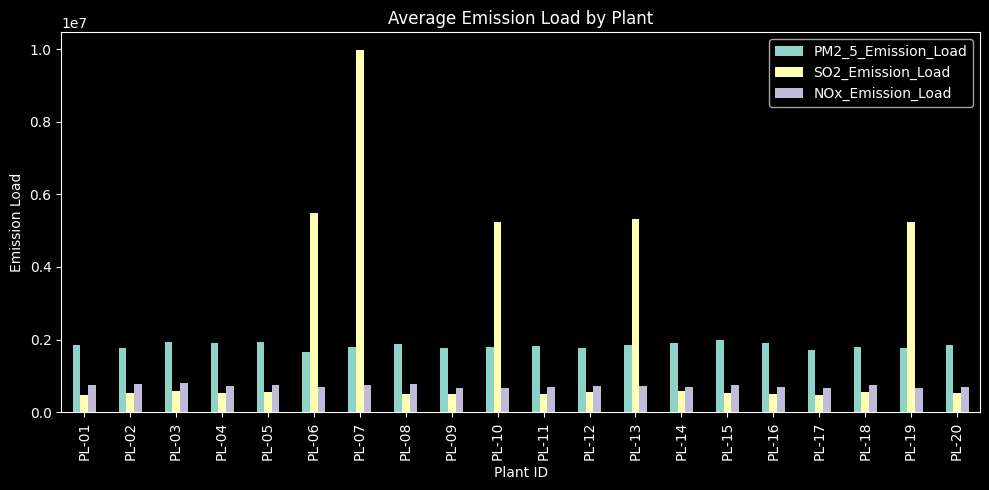

In [850]:
emission = (
    df.groupby("Plant_ID")[[
        "PM2_5_Emission_Load",
        "SO2_Emission_Load",
        "NOx_Emission_Load"
    ]]
    .mean()
)

emission.plot(kind="bar", figsize=(10,5))

plt.title("Average Emission Load by Plant")
plt.xlabel("Plant ID")
plt.ylabel("Emission Load")

plt.tight_layout()
plt.show()

## 13. Change‑point detection for drift alarms.

In [851]:
df_sorted=df.sort_values(["Plant_ID", "TS"]).copy()

In [852]:
df_sorted["PM2_5_Alarm"] = (df_sorted.groupby("Plant_ID")["PM2_5"].diff())
df_sorted["SO2_Alarm"] = (df_sorted.groupby("Plant_ID")["SO2"].diff())
df_sorted["NOx_Alarm"] = (df_sorted.groupby("Plant_ID")["NOx"].diff())

In [853]:
min_limit = 20

In [854]:
var={True:'No Alaram Needed', False:'Alaram Needed'}

In [855]:
df_sorted["PM2_5_Alarm_Flag"] = (df_sorted["PM2_5_Alarm"].abs() < min_limit).map(var)
df_sorted["SO2_Alarm_Flag"] = (df_sorted["SO2_Alarm"].abs() < min_limit).map(var)
df_sorted["NOx_Alarm_Flag"] = (df_sorted["NOx_Alarm"].abs() < min_limit).map(var)

In [856]:
df_sorted.loc[100:200,["TS","PM2_5_Alarm", "PM2_5_Alarm_Flag","SO2_Alarm", "SO2_Alarm_Flag","NOx_Alarm", "NOx_Alarm_Flag"]].head()

,TS,PM2_5_Alarm,PM2_5_Alarm_Flag,SO2_Alarm,SO2_Alarm_Flag,NOx_Alarm,NOx_Alarm_Flag
100,2026-03-13 18:06:00,-135297.76,Alaram Needed,-21390.70,Alaram Needed,-48853.14,Alaram Needed
101,2026-03-13 19:30:00,94.35,Alaram Needed,-0.47,No Alaram Needed,-42.82,Alaram Needed
102,2026-03-13 19:36:00,45393.41,Alaram Needed,28801.17,Alaram Needed,83435.96,Alaram Needed
103,2026-03-13 21:28:00,-45332.50,Alaram Needed,-28815.41,Alaram Needed,-83445.35,Alaram Needed
104,2026-03-14 00:02:00,77272.50,Alaram Needed,19945.41,Alaram Needed,29955.35,Alaram Needed


## 14. Gap‑filled vs raw comparison metrics.

In [857]:
df_raw=pd.read_csv('pollution_raw_data.csv')

In [858]:
df_raw[['PM2_5','SO2','NOx']].isnull().sum()

PM2_5    307
SO2      324
NOx      280
dtype: int64

In [859]:
df_raw["PM2_5_Raw"] = df_raw["PM2_5"]
df_raw["SO2_Raw"] = df_raw["SO2"]
df_raw["NOx_Raw"] = df_raw["NOx"]

df_raw["PM2_5_Filled"] = df_raw["PM2_5"].fillna(df_raw["PM2_5"].mean())
df_raw["SO2_Filled"] = df_raw["SO2"].fillna(df_raw["SO2"].mean())
df_raw["NOx_Filled"] = df_raw["NOx"].fillna(df_raw["NOx"].mean())

df_raw["PM2_5_Status"] = np.where(df_raw["PM2_5_Raw"].isna(), "Gap Filled", "No Change")
df_raw["SO2_Status"] = np.where(df_raw["SO2_Raw"].isna(), "Gap Filled", "No Change")
df_raw["NOx_Status"] = np.where(df_raw["NOx_Raw"].isna(), "Gap Filled", "No Change")

In [860]:
print(df_raw[["Plant_ID","PM2_5_Raw", "PM2_5_Filled", "PM2_5_Status","SO2_Raw", "SO2_Filled", "SO2_Status","NOx_Raw", "NOx_Filled", "NOx_Status"]].head(30))

   Plant_ID  PM2_5_Raw  PM2_5_Filled PM2_5_Status    SO2_Raw  SO2_Filled  \
0     PL-11     59.101     59.101000    No Change     39.112      39.112   
1     PL-05     83.134     83.134000    No Change     26.186      26.186   
2     PL-10    299.073    299.073000    No Change     59.344      59.344   
3     PL-04     39.035     39.035000    No Change     24.661      24.661   
4     PL-06    146.540    146.540000    No Change     47.534      47.534   
5     PL-18    127.864    127.864000    No Change     30.846      30.846   
6     PL-19    441.111    441.111000    No Change     14.619      14.619   
7     PL-18    129.840    129.840000    No Change     42.299      42.299   
8     PL-18    123.836    123.836000    No Change  99999.000   99999.000   
9     PL-16     68.047     68.047000    No Change     59.063      59.063   
10    PL-15        NaN    138.556204   Gap Filled     49.033      49.033   
11    PL-09        NaN    138.556204   Gap Filled     80.659      80.659   
12    PL-15 

In [861]:
df_raw["PM2_5_Status"].value_counts()

PM2_5_Status
No Change     14943
Gap Filled      307
Name: count, dtype: int64

In [862]:
df_raw["SO2_Status"].value_counts()

SO2_Status
No Change     14926
Gap Filled      324
Name: count, dtype: int64

In [863]:
df_raw["NOx_Status"].value_counts()

NOx_Status
No Change     14970
Gap Filled      280
Name: count, dtype: int64

## 15. Regulatory reporting tables (Stack, Ambient).

In [864]:
stack = df[df["Source_Type"]=="stack"]

In [865]:
stack_report = stack.groupby("Plant_ID")[["PM2_5","SO2","NOx"]].mean()

In [866]:
ambient = df[df["Source_Type"]=="ambient"]

In [867]:
ambient_report = ambient.groupby("Plant_ID")[["PM2_5","SO2","NOx"]].mean()

In [868]:
report = pd.merge(
    stack_report,
    ambient_report,
    on="Plant_ID",
    how="outer",
    suffixes=("_Stack", "_Ambient")
)

In [869]:
report

,PM2_5_Stack,SO2_Stack,NOx_Stack,PM2_5_Ambient,SO2_Ambient,NOx_Ambient
Plant_ID,,,,,,
PL-01,46178.715921,12677.552844,18623.946923,61073.242486,13672.020734,21658.653277
PL-02,49465.885194,14776.482665,21512.509476,47922.428663,15557.571497,22062.489358
PL-03,52582.449463,15941.989024,22436.649976,58254.686890,14689.443720,23910.163110
PL-04,44148.579256,13881.222878,19224.953846,60344.650564,14928.109333,22993.878410
PL-05,51626.780438,14613.823869,19811.771800,58525.946337,14681.258663,20325.134302
PL-06,44747.401759,255128.417108,19240.777422,43923.789312,17842.636000,19426.190438
PL-07,51050.256514,15378.476202,21338.496659,37723.966452,550358.471667,15907.215753
PL-08,52330.796289,13178.260474,20726.571711,56196.030924,16406.570870,24545.741902
PL-09,45194.741831,13039.992300,16927.632324,53431.333058,14666.812039,19938.474515


## 16. Model features for forecasting PM2.5.

In [870]:
# print(df.columns.tolist())

In [871]:
df = df.sort_values(["Plant_ID", "TS"])

In [872]:
df["PM2_5_Lag_1"] = df.groupby("Plant_ID")["PM2_5"].shift(1)
df["PM2_5_Lag_2"] = df.groupby("Plant_ID")["PM2_5"].shift(2)

In [873]:
df["PM2_5_Rolling_Mean_3"] = (df.groupby("Plant_ID")["PM2_5"].transform(lambda x: x.rolling(window=3, min_periods=1).mean()))
df["PM2_5_Rolling_STD_3"] = (df.groupby("Plant_ID")["PM2_5"].transform(lambda x: x.rolling(window=3, min_periods=1).std()).fillna(0))

In [874]:
df["Is_Weekend"] = df["TS"].dt.dayofweek.isin([5, 6]).astype(int)
df[["Plant_ID", "TS", "PM2_5", "PM2_5_Lag_1", "PM2_5_Lag_2", "PM2_5_Rolling_Mean_3", "PM2_5_Rolling_STD_3", "Hour", "Day", "Month", "Is_Weekend"]].head()

,Plant_ID,TS,PM2_5,PM2_5_Lag_1,PM2_5_Lag_2,PM2_5_Rolling_Mean_3,PM2_5_Rolling_STD_3,Hour,Day,Month,Is_Weekend
0,PL-01,2026-01-03 06:18:00,157.84,NaN,NaN,157.840000,0.000000,6,Saturday,2026-01,1
1,PL-01,2026-01-03 11:59:00,83870.00,157.84,NaN,42013.920000,59193.436004,11,Saturday,2026-01,1
2,PL-01,2026-01-03 15:30:00,155.72,83870.00,157.84,28061.186667,48331.850113,15,Saturday,2026-01,1
3,PL-01,2026-01-03 15:35:00,153280.00,155.72,83870.00,79101.906667,76673.413364,15,Saturday,2026-01,1
4,PL-01,2026-01-03 15:54:00,71150.00,153280.00,155.72,74861.906667,76629.595912,15,Saturday,2026-01,1


## 17. Hotspot ranking by persistence and intensity.

In [875]:
pm_limit = 60
so2_limit = 80
nox_limit = 80

In [876]:
df["PM2_5_Hotspot"] = df["PM2_5"] > pm_limit
df["SO2_Hotspot"] = df["SO2"] > so2_limit
df["NOx_Hotspot"] = df["NOx"] > nox_limit

In [877]:
pm_intensity = df.groupby("Plant_ID")["PM2_5"].mean()
so2_intensity = df.groupby("Plant_ID")["SO2"].mean()
nox_intensity = df.groupby("Plant_ID")["NOx"].mean()

In [878]:
pm_persistence = df.groupby("Plant_ID")["PM2_5_Hotspot"].sum()
so2_persistence = df.groupby("Plant_ID")["SO2_Hotspot"].sum()
nox_persistence = df.groupby("Plant_ID")["NOx_Hotspot"].sum()

In [879]:
hotspot_report = pd.DataFrame({
    "PM2_5_Intensity": pm_intensity,
    "PM2_5_Persistence": pm_persistence,
    "SO2_Intensity": so2_intensity,
    "SO2_Persistence": so2_persistence,
    "NOx_Intensity": nox_intensity,
    "NOx_Persistence": nox_persistence
})

In [880]:
hotspot_report.head()

,PM2_5_Intensity,PM2_5_Persistence,SO2_Intensity,SO2_Persistence,NOx_Intensity,NOx_Persistence
Plant_ID,,,,,,
PL-01,51158.634220,656,13379.944630,324,20739.550754,366
PL-02,49242.216419,688,15039.532344,332,21486.470078,377
PL-03,53805.307942,642,15854.377747,321,22295.246885,367
PL-04,52763.057373,668,14657.939035,331,20350.024973,352
PL-05,53352.270666,664,15218.180272,317,20519.958845,361


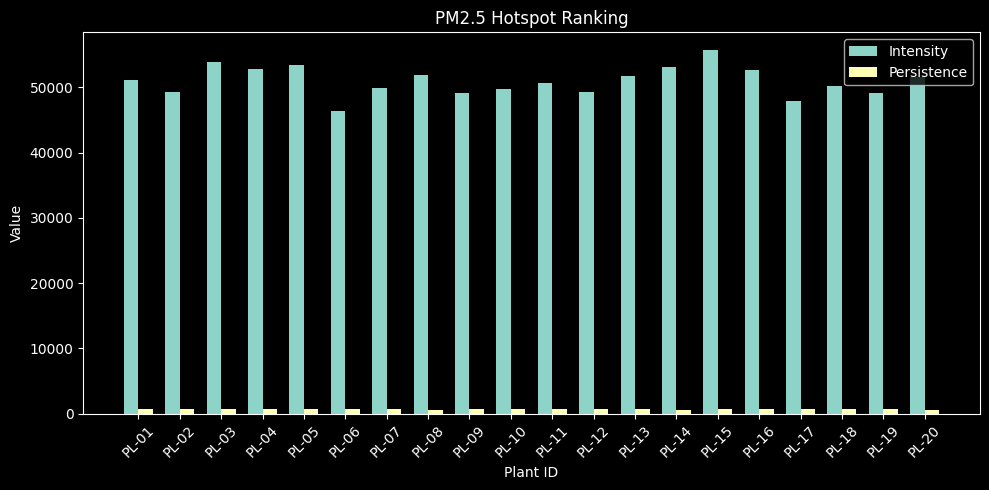

In [881]:
plt.figure(figsize=(10,5))

x = np.arange(len(hotspot_report.index))
width = 0.35

plt.bar(x-width/2, hotspot_report["PM2_5_Intensity"], width, label="Intensity")
plt.bar(x+width/2, hotspot_report["PM2_5_Persistence"], width, label="Persistence")

plt.title("PM2.5 Hotspot Ranking")
plt.xlabel("Plant ID")
plt.ylabel("Value")
plt.xticks(x, hotspot_report.index, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

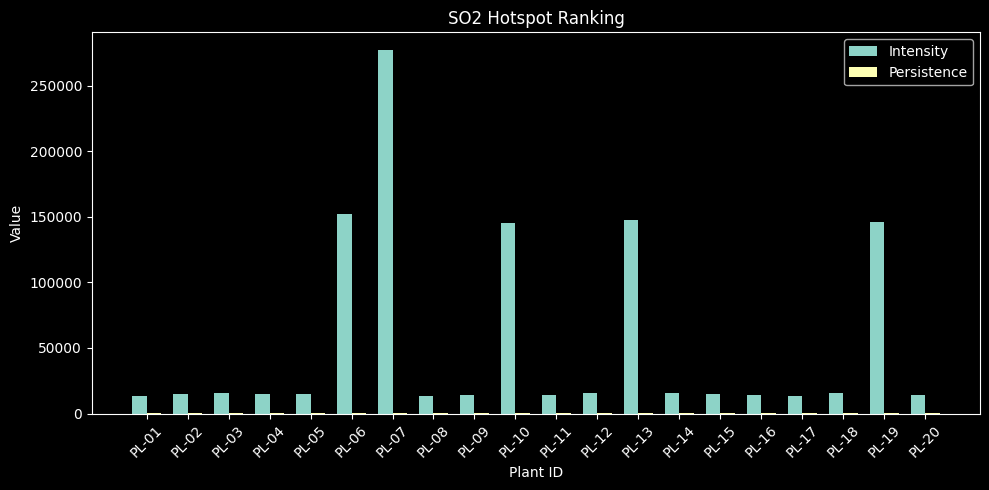

In [882]:
plt.figure(figsize=(10,5))

x = np.arange(len(hotspot_report.index))
width = 0.35

plt.bar(x-width/2, hotspot_report["SO2_Intensity"], width, label="Intensity")
plt.bar(x+width/2, hotspot_report["SO2_Persistence"], width, label="Persistence")

plt.title("SO2 Hotspot Ranking")
plt.xlabel("Plant ID")
plt.ylabel("Value")
plt.xticks(x, hotspot_report.index, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

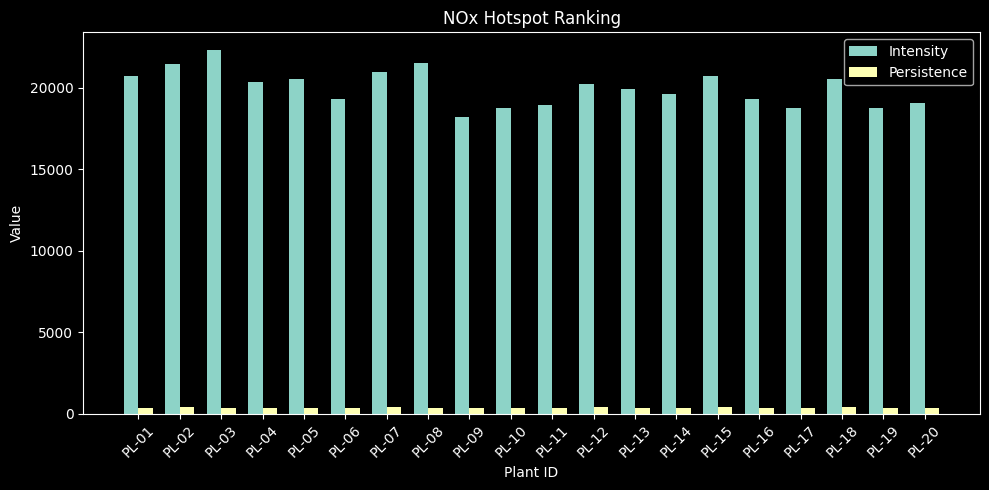

In [883]:
plt.figure(figsize=(10,5))

x = np.arange(len(hotspot_report.index))
width = 0.35

plt.bar(x-width/2, hotspot_report["NOx_Intensity"], width, label="Intensity")
plt.bar(x+width/2, hotspot_report["NOx_Persistence"], width, label="Persistence")

plt.title("NOx Hotspot Ranking")
plt.xlabel("Plant ID")
plt.ylabel("Value")
plt.xticks(x, hotspot_report.index, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

## 18. Control measure impact evaluation (pre/post).

In [884]:
df["Period"] = df["TS"].dt.month.apply(lambda x: "Before" if x <= 6 else "After")

In [885]:
impact = (df.groupby("Period")[["PM2_5", "SO2", "NOx"]].mean().round(2).reset_index())

In [886]:
before = impact[impact["Period"] == "Before"].iloc[0]
after = impact[impact["Period"] == "After"].iloc[0]

In [887]:
comparison = pd.DataFrame({
    "Pollutant": ["PM2_5", "SO2", "NOx"],
    "Before": [before["PM2_5"], before["SO2"], before["NOx"]],
    "After": [after["PM2_5"], after["SO2"], after["NOx"]]
})

In [888]:
comparison["Percent_Change"] = ((comparison["After"] - comparison["Before"])/ comparison["Before"] * 100).round(2)


In [889]:
comparison

,Pollutant,Before,After,Percent_Change
0,PM2_5,51337.91,49273.59,-4.02
1,SO2,47887.61,84204.35,75.84
2,NOx,19982.28,20092.59,0.55


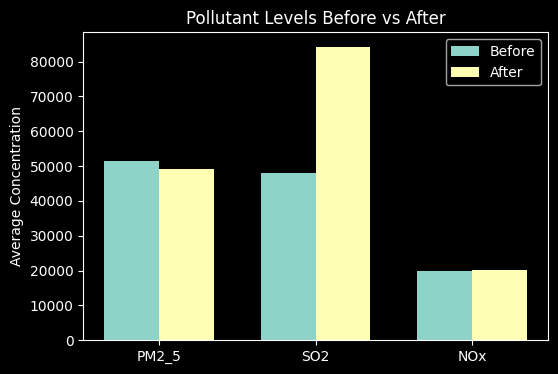

In [890]:
plt.figure(figsize=(6,4))

x = np.arange(len(comparison["Pollutant"]))
width = 0.35

plt.bar(x-width/2, comparison["Before"], width, label="Before")
plt.bar(x+width/2, comparison["After"], width, label="After")

plt.xticks(x, comparison["Pollutant"])
plt.ylabel("Average Concentration")
plt.title("Pollutant Levels Before vs After")
plt.legend()

plt.show()

## 19. Compliance penalty estimation.

In [891]:
df['Penalty']=0

In [892]:
df["Penalty"] += np.where(df["PM2_5"] > 60, 5000, 0)
df["Penalty"] += np.where(df["SO2"] > 80, 3000, 0)
df["Penalty"] += np.where(df["NOx"] > 80, 3000, 0)

In [893]:
df[["Plant_ID", "PM2_5", "SO2", "NOx", "Penalty"]].head()

,Plant_ID,PM2_5,SO2,NOx,Penalty
0,PL-01,157.84,50.28,26.06,5000
1,PL-01,83870.00,29840.00,35490.00,11000
2,PL-01,155.72,18.32,50.01,5000
3,PL-01,153280.00,62150.00,28010.00,11000
4,PL-01,71150.00,11060.00,122410.00,11000


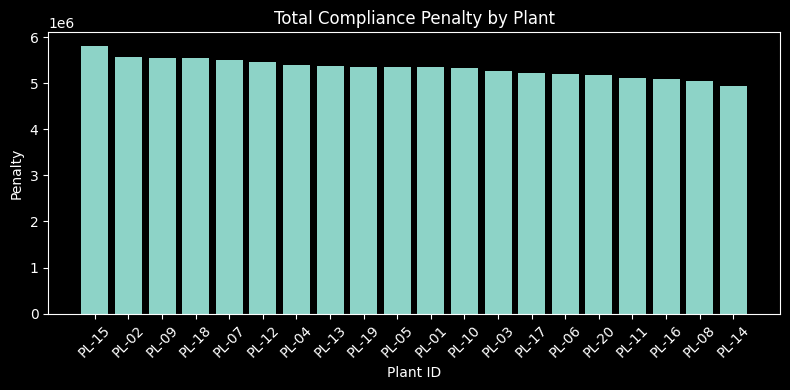

In [894]:
penalty_summary = (
    df.groupby("Plant_ID")["Penalty"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,4))
plt.bar(penalty_summary.index, penalty_summary.values)

plt.title("Total Compliance Penalty by Plant")
plt.xlabel("Plant ID")
plt.ylabel("Penalty")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 20. Open data extract with privacy safeguards.

In [895]:
public_data = df.copy()

In [896]:
public_data = public_data.drop(columns=[
    "Sensor_serial",
    "Analyst_ID",
    "Audit_Trail",
    "Inspector_notes"
])

In [897]:
public_data.head(30)

,Plant_ID,TS,Record_ID,Stack_ID,Source_Type,PM2_5,SO2,NOx,Unit,LatLon,...,PM2_5_Lag_1,PM2_5_Lag_2,PM2_5_Rolling_Mean_3,PM2_5_Rolling_STD_3,Is_Weekend,PM2_5_Hotspot,SO2_Hotspot,NOx_Hotspot,Period,Penalty
0,PL-01,2026-01-03 06:18:00,E100013,ST-008,lab,157.84,50.28,26.06,ug/m3,"14.2265, 77.6492",...,NaN,NaN,157.840000,0.000000,1,True,False,False,Before,5000
1,PL-01,2026-01-03 11:59:00,E100124,ST-002,stack,83870.00,29840.00,35490.00,ug/m3,"14.2265, 77.6492",...,157.84,NaN,42013.920000,59193.436004,1,True,True,True,Before,11000
2,PL-01,2026-01-03 15:30:00,E100193,ST-002,ambient,155.72,18.32,50.01,ug/m3,"14.2265, 77.6492",...,83870.00,157.84,28061.186667,48331.850113,1,True,False,False,Before,5000
3,PL-01,2026-01-03 15:35:00,E100197,ST-002,stack,153280.00,62150.00,28010.00,ug/m3,"14.2265, 77.6492",...,155.72,83870.00,79101.906667,76673.413364,1,True,True,True,Before,11000
4,PL-01,2026-01-03 15:54:00,E100207,ST-002,inspection,71150.00,11060.00,122410.00,ug/m3,"14.2265, 77.6492",...,153280.00,155.72,74861.906667,76629.595912,1,True,True,True,Before,11000
5,PL-01,2026-01-03 16:25:00,E100216,ST-008,ambient,279.26,20.39,112.83,ug/m3,"14.2265, 77.6492",...,71150.00,153280.00,74903.086667,76569.385885,1,True,False,True,Before,8000
6,PL-01,2026-01-03 18:20:00,E100252,ST-002,ambient,59.58,30.52,69.09,ug/m3,"14.2265, 77.6492",...,279.26,71150.00,23829.613333,40980.804171,1,False,False,False,Before,0
7,PL-01,2026-01-03 19:08:00,E100268,ST-002,stack,152.31,15.26,82.44,ug/m3,"14.2265, 77.6492",...,59.58,279.26,163.716667,110.283315,1,True,False,True,Before,8000
8,PL-01,2026-01-03 20:13:00,E100293,ST-008,stack,115640.00,13250.00,38920.00,ug/m3,"14.2265, 77.6492",...,152.31,59.58,38617.296667,66703.633869,1,True,True,True,Before,11000
9,PL-01,2026-01-03 21:42:00,E100317,ST-008,ambient,117070.00,44240.00,35770.00,ug/m3,"14.2265, 77.6492",...,115640.00,152.31,77620.770000,67093.464258,1,True,True,True,Before,11000


In [898]:
df.shape

(14883, 106)